<a href="https://colab.research.google.com/github/zeegy99/Quant_Backtesting_Models/blob/main/Momentum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Returns: 17.33% Sharpe Average Across Arbitrary Dataset of ['AAPL', 'META', 'MSFT', 'NVDA', '^GSPC', '^DJI', '^IXIC'] Over the past 10 years using strategy extrapolated from TSLA.



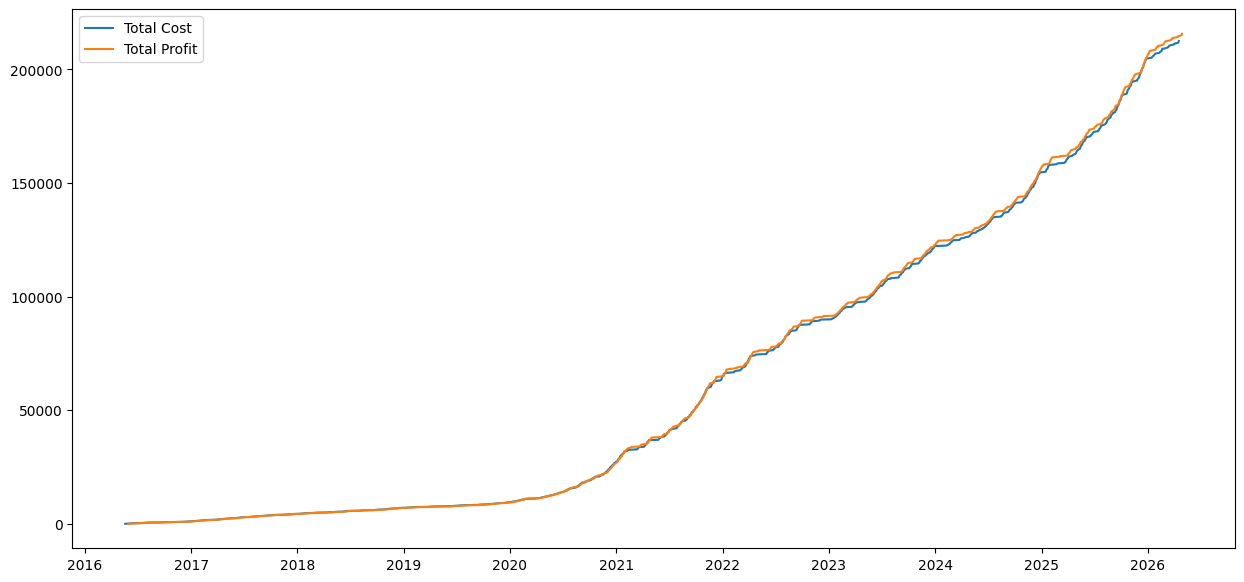

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(purchase_dates, total_cost)
plt.plot(sell_dates, total_profit)
plt.legend(['Total Cost', 'Total Profit'])
plt.show()

3166.664219856262


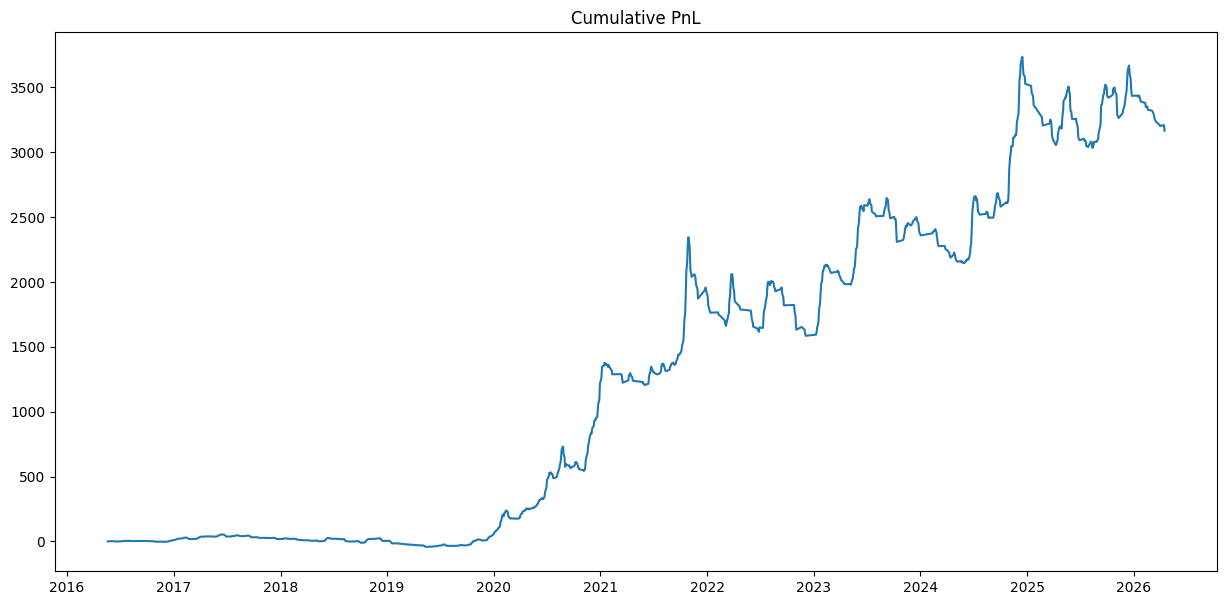

In [ ]:
pnl_per_trade = [float(sell[i]) - float(purchase[i]) for i in range(len(purchase))]

cumulative_pnl = []
running = 0
for p in pnl_per_trade:
    running += p
    cumulative_pnl.append(running)

print(sum(pnl_per_trade))  # confirm 3166

plt.figure(figsize=(15, 7))
plt.plot(purchase_dates, cumulative_pnl)  # use purchase_dates, not graph_purchase
plt.title("Cumulative PnL")
plt.show()

/tmp/ipykernel_4148/130051658.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y')
[*********************100%***********************]  1 of 1 completed


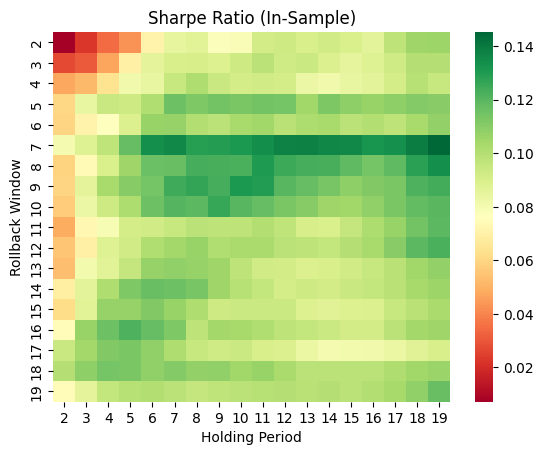

In [ ]:
import numpy as np
import seaborn as sns
import yfinance as yf
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

def run_strategy(df, rollback_window, holding_period, ticker):
    purchase, sell, purchase_dates, sell_dates = [], [], [], []

    for j in range(rollback_window + 1, len(df) - holding_period):
        i = j - 1
        prev = i - rollback_window
        prev_close = df.iloc[prev]['Close'][ticker]
        curr_close = df.iloc[i]['Close'][ticker]

        if prev_close < curr_close:
            purchase.append(df.iloc[j]['Open'][ticker])
            purchase_dates.append(df.index[j])
            sell.append(df.iloc[j + holding_period]['Open'][ticker])
            sell_dates.append(df.index[j + holding_period])

    pnl = [float(sell[i]) - float(purchase[i]) for i in range(len(purchase))]
    sharpe = np.mean(pnl) / np.std(pnl) if np.std(pnl) > 0 else 0
    return sharpe, sum(pnl), pnl, purchase_dates
ticker = 'TSLA'
df = yf.download(ticker, period='10y')
split = int(len(df) * 0.7)

df_train = df.iloc[:split]
df_test  = df.iloc[split:]
windows  = range(2, 20)
holdings = range(2, 20)

heatmap_data = np.zeros((len(list(windows)), len(list(holdings))))

for wi, w in enumerate(windows):
    for hi, h in enumerate(holdings):
        sharpe, _, _, _ = run_strategy(df_train, w, h, ticker)
        heatmap_data[wi, hi] = sharpe

sns.heatmap(heatmap_data, xticklabels=holdings, yticklabels=windows, cmap="RdYlGn")
plt.xlabel("Holding Period")
plt.ylabel("Rollback Window")
plt.title("Sharpe Ratio (In-Sample)")
plt.show()

In [ ]:
import bea

In [ ]:
#Generalizing to other companies

def test_on_world(w, h):

  companies = ['AAPL', 'META', 'MSFT', 'NVDA', '^GSPC', '^DJI', '^IXIC']
  sharpes = []
  total_returns = []
  for i in range(len(companies)):
    sharpe, total_return, pnl, dates =run_strategy(yf.download(companies[i], period='10y', auto_adjust = True), w, h, companies[i])
    sharpes.append(sharpe)
    total_returns.append(total_return)
  return sharpes, total_returns

In [ ]:
best = [0, 0, 0]
windows  = range(2, 20)
holdings = range(2, 20)
for wi, w in enumerate(windows):
    for hi, h in enumerate(holdings):

      if heatmap_data[wi, hi] >= .1375: #Threshold to test the strategy
        print([wi, hi], heatmap_data[wi, hi])
        sharpe, total_pnl, pnl, purchase_dates = run_strategy(df_test, w, h, 'TSLA')
        print(f"Sharpe: {sharpe}, Total PnL: {total_pnl}")

        print('testing on world')
        sharpes, total_returns = test_on_world(w, h)
        print(f"Sharpes: {sum(sharpes)/len(sharpes)}, Total Return Average: {sum(total_returns)/len(total_returns)}")
        print(sharpes, total_returns)

# print(best)


[5, 11] 0.13801605717386023
Sharpe: 0.11400962237740286, Total PnL: 1737.6300354003906
testing on world


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Sharpes: 0.13708208188338109, Total Return Average: 53080.284255783765
[np.float64(0.16045594481924744), np.float64(0.05874993688399707), np.float64(0.11829500188303659), np.float64(0.1413170903407618), np.float64(0.1776490689224754), np.float64(0.13517380304757037), np.float64(0.1679337272865788)] [1932.4005036301867, 2213.5622760442707, 2430.9697684272196, 1397.0964269549654, 35200.95251464844, 189963.125, 138423.88330078125]
[5, 16] 0.13891463207025878


[*********************100%***********************]  1 of 1 completed

Sharpe: 0.13591056383103997, Total PnL: 2314.5300903320312
testing on world


...

Sharpes: 0.16876417446152162, Total Return Average: 73554.55948358665
[np.float64(0.1928971846245761), np.float64(0.09932770626235592), np.float64(0.1357033522794259), np.float64(0.19489951228516678), np.float64(0.20443532364183065), np.float64(0.16494473496402376), np.float64(0.18914140717327227)] [2710.586901502289, 4241.7087015804755, 3223.748986749713, 2273.8340755474906, 48125.62609863281, 269137.904296875, 185168.50732421875]
[5, 17] 0.1452793180779108


[*********************100%***********************]  1 of 1 completed

Sharpe: 0.14617090880798483, Total PnL: 2533.450149536133
testing on world



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Sharpes: 0.173341014842967, Total Return Average: 76432.27799148855
[np.float64(0.19615665847975997), np.float64(0.11462532899575649), np.float64(0.1367436307995718), np.float64(0.20014154067893591), np.float64(0.20726824042178607), np.float64(0.1636402619180381), np.float64(0.19481144260692063)] [2809.8765792252407, 4960.279777187646, 3328.092193792156, 2379.1765161913168, 50182.23718261719, 275988.76953125, 195377.51416015625]


Testing the Strategy in practice: `Starting 4/30.

We will pull data at the end of the trading day 1 minute before close? Doesn't really matter tbf


In [ ]:
#Testing with limited capital to see what happens

starting_capital = 100,000

#evenly spread throughout the days?? this assumption can be changed



In [ ]:
import yfinance as yf

df = yf.download('TSLA', period='1mo')
print(df)

/tmp/ipykernel_10298/2184966686.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSLA', period='1mo')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2026-03-30  355.279999  367.290009  352.140015  365.859985   67954400
2026-03-31  371.750000  373.329987  361.000000  361.510010   75534900
2026-04-01  381.260010  383.140015  374.079987  378.630005   58683800
2026-04-02  360.589996  370.279999  359.029999  364.200012   83031200
2026-04-06  352.820007  367.720001  346.640015  362.589996   77697600
2026-04-07  346.649994  348.019989  337.239990  346.440002   74515400
2026-04-08  343.250000  364.500000  339.670013  363.790009   78838600
2026-04-09  345.619995  348.880005  337.250000  343.149994   62164000
2026-04-10  348.950012  350.359985  342.739990  346.290009   51336000
2026-04-13  352.420013  356.350006  348.570007  350.070007   53617500
2026-04-14  364.200012  367.630005  354.769989  357.670013   59979600
2026-04-15  391.9500